# Intro to Data Science: Final Project
## Predicting Customer Subscription Status
Justen Hilliard | December 15, 2025 | DATA 201 : Section 3

- My project analyzes customer shopping behavior to predict wheter a customer will subscribe to a service based on demographic and purchasing patterns.

## Real-World Problem

Businesses want to understand which customers are likely to subscribe target promotions more effectively and improve customer retention.

Predicting subscription behavior allows companies to:
- Reduce marketing costs
- Personalize offers
- See what products bring users
- Improve customer lifetime value

## Machine Learning Task
- **Task Type:** Binary Classification
- **Target Variable:** 'Subscription Status' (Yes/No)

- Goal: Given a customer's shopping behaviour, predict whether they will subscribe.


In [65]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, make_scorer)


# Data Collection

In [66]:
# Loading the dataset & previews the first 5 w/ head()
df = pd.read_csv("shopping_behavior.csv")
df.head()

# Dimensions & Datatypes
print("Dataset shape:", df.shape)
df.info()



Dataset shape: (3900, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Use

# Exploratory Data Analysis (EDA)

In [67]:
# Missing Vals
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

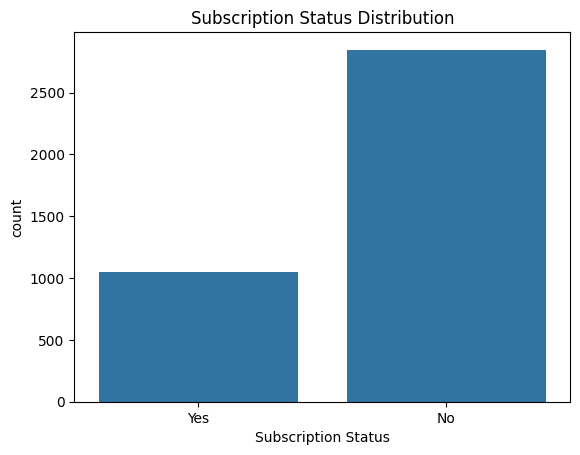

In [68]:
# Visualization of user subscription status

sns.countplot(x= "Subscription Status", data = df)
plt.title("Subscription Status Distribution")
plt.show() 

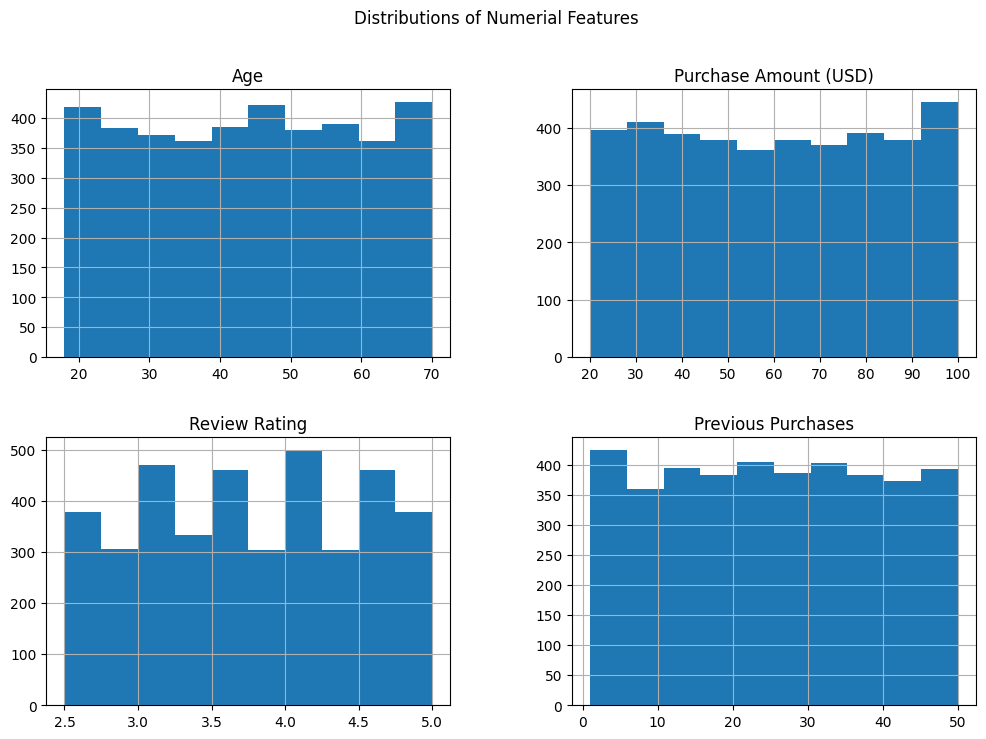

In [69]:
# Features related to customer behavior and potential spending habits
nfeatures = [
    "Age", 
    "Purchase Amount (USD)", 
    "Review Rating", 
    "Previous Purchases", 
]

# Histogram w/ ranges, skewness, and outliers
df[nfeatures].hist(figsize=(12,8))
plt.suptitle("Distributions of Numerial Features")
plt.tight_layout
plt.show()

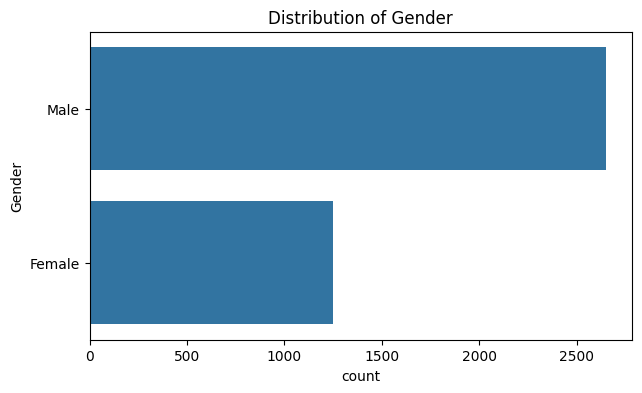

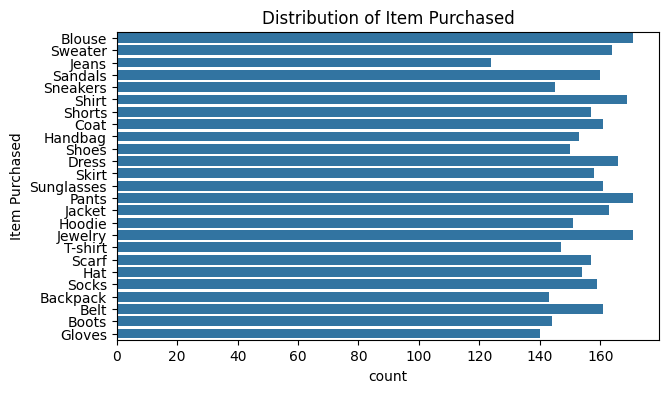

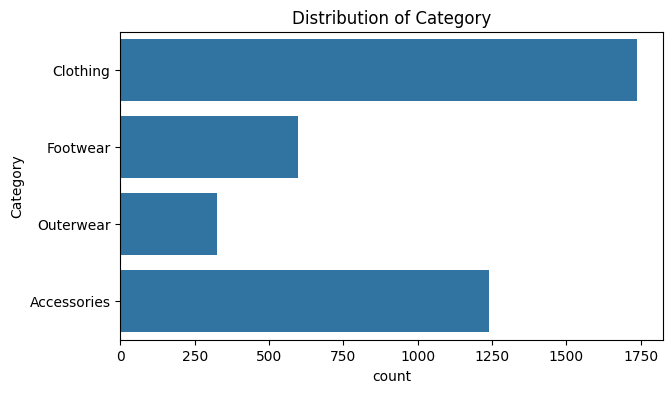

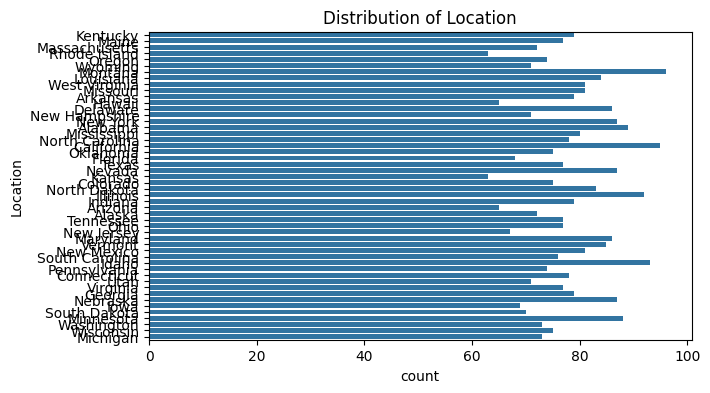

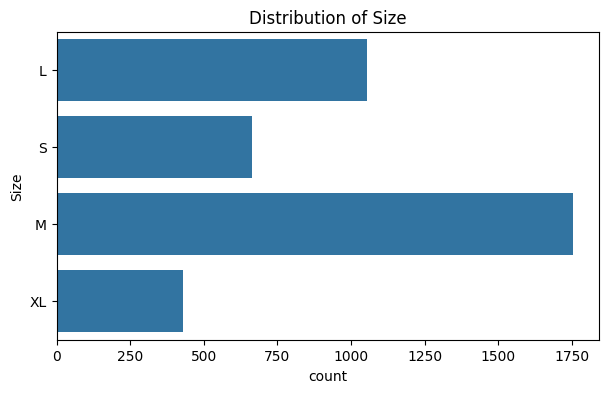

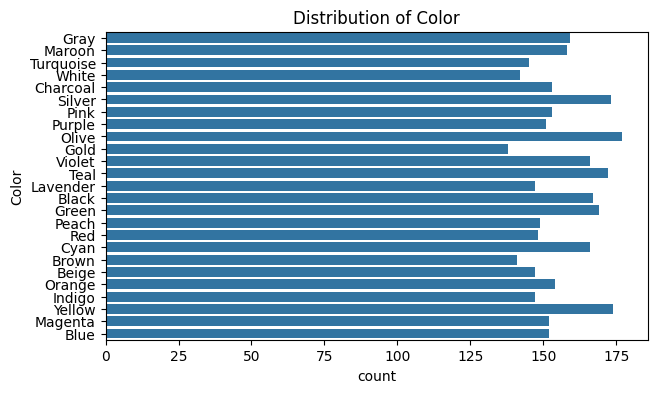

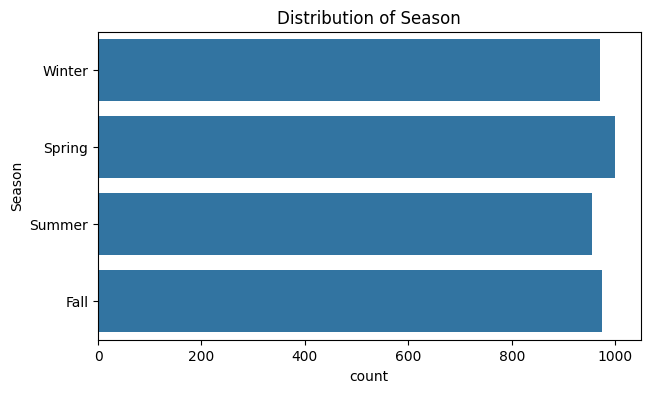

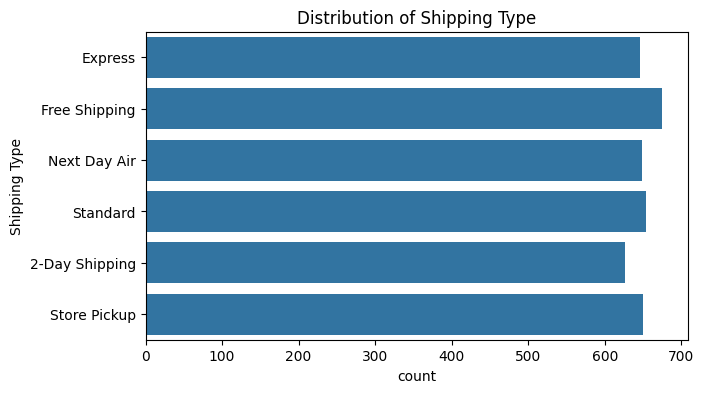

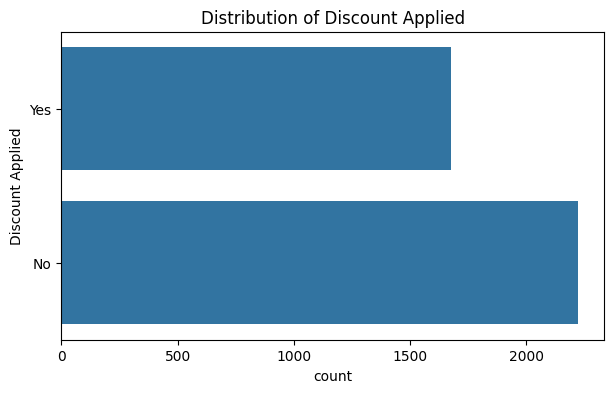

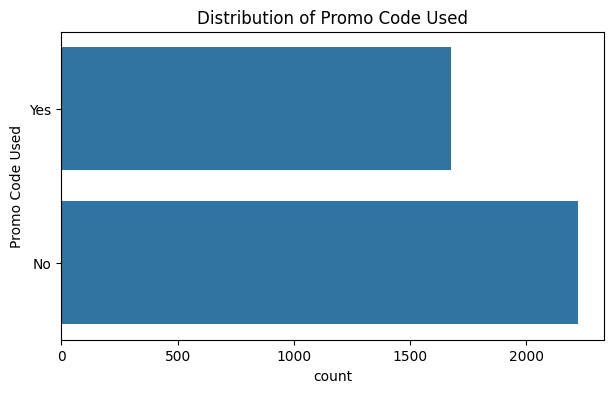

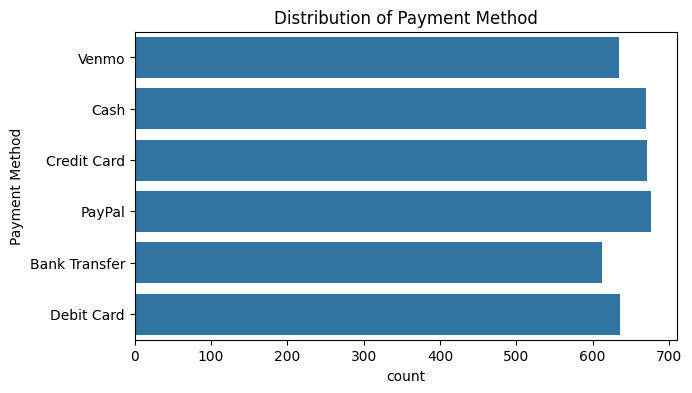

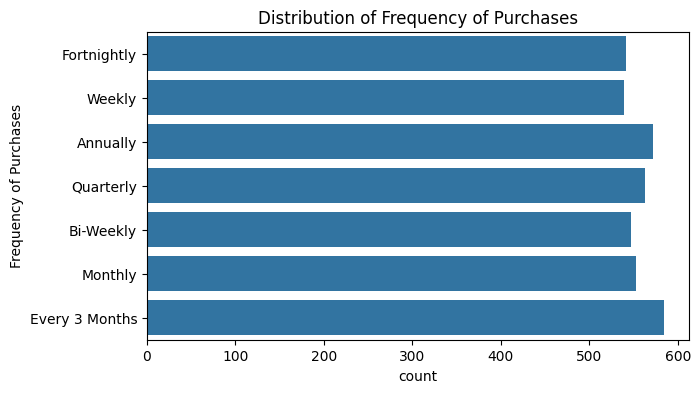

In [70]:
# Categorical features that might reflect prefs and engagement
cfeatures = [
    "Gender",
    "Item Purchased",
    "Category",
    "Location",
    "Size",
    "Color",
    "Season",
    "Shipping Type",
    "Discount Applied",
    "Promo Code Used",
    "Payment Method",
    "Frequency of Purchases"
]

# Count plots
# Displays the most dominant cat. 
for col in cfeatures:
    plt.figure(figsize=(7,4))
    sns.countplot(y=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

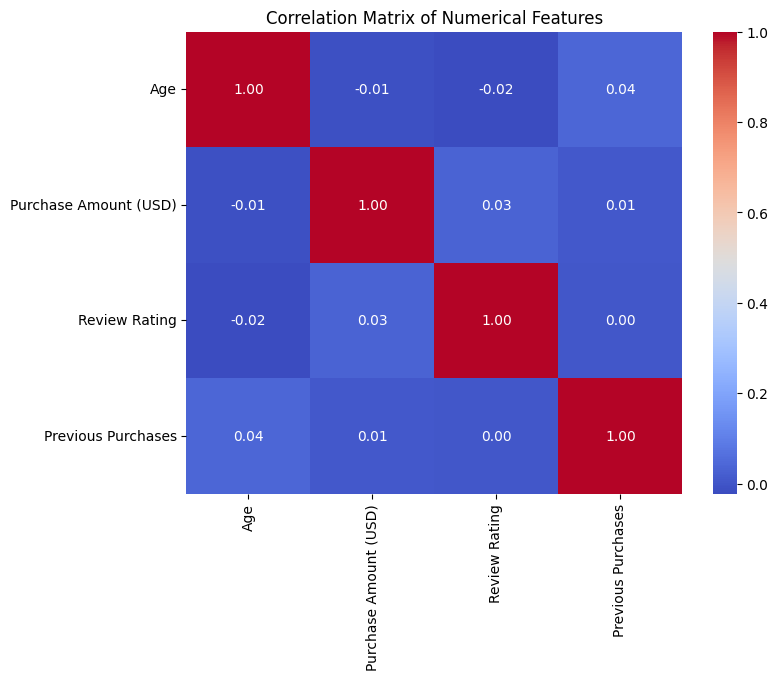

In [71]:
ndf = df[nfeatures].select_dtypes(include="number")
plt.figure(figsize=(8,6))

sns.heatmap(ndf.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# Data Preparation

In [72]:
# Features & Target Vars
X = df.drop(columns=["Customer ID", "Subscription Status"])
y = df["Subscription Status"]

# Numerical & Categorical Columns
ncols = X.select_dtypes(include= ["int64", "float64"]).columns
catcols = X.select_dtypes(include= ["object"]).columns


In [73]:
# Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", nfeatures),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cfeatures)
    ]
)

# Training, Validation, and Test Splitting

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size = 0.3, random_state = 42, stratify = y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size= 0.5, random_state = 42, stratify= y_temp
)

# Model Selection

In [74]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        solver="liblinear"  # faster for small datasets
    ),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10,random_state=42, n_jobs = -1),
    "SVM": SVC(kernel="linear", probability=True),
    "Naive Bayes": GaussianNB()
}

In [75]:
params = {
    "KNN": {"model__n_neighbors": [3,5,7]},
    "Decision Tree": {"model__max_depth": [None,5,10,20]},
    "Random Forest": 
    {
        "model__n_estimators": [100,200],
        "model__max_depth": [None,10]
    },
    "SVM": 
    {
        "model__C": [0.1,1,10],
        "model__kernel": ["linear","rbf"]
    }
}


# Model Training

In [76]:
# Training & Validation Evaluation
results = []
best_models = {}

for name, model in models.items():

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    best_models[name] = pipe

    y_pred = pipe.predict(X_val)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred, pos_label="Yes"),
        "Recall": recall_score(y_val, y_pred, pos_label="Yes"),
        "F1": f1_score(y_val, y_pred, pos_label="Yes")
    })

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
results_df


,Model,Accuracy,Precision,Recall,F1
3,Random Forest,0.832479,0.617188,1.000000,0.763285
5,Naive Bayes,0.832479,0.617188,1.000000,0.763285
4,SVM,0.815385,0.613636,0.854430,0.714286
2,Decision Tree,0.825641,0.647368,0.778481,0.706897
0,Logistic Regression,0.813675,0.621891,0.791139,0.696379
1,KNN,0.705983,0.412500,0.208861,0.277311


# Model Evaluation

In [77]:
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    return {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, pos_label="Yes", zero_division=0),
        "Recall": recall_score(y, y_pred, pos_label="Yes", zero_division=0),
        "F1": f1_score(y, y_pred, pos_label="Yes", zero_division=0)
    }


In [78]:
# Training Results
tresults = []

for name, model in best_models.items():
    metrics = evaluate_model(model, X_train, y_train)
    metrics["Model"] = name
    tresults.append(metrics)

tdf = pd.DataFrame(tresults).set_index("Model")
tdf


,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.858608,0.687300,0.873813,0.769415
KNN,0.788645,0.702020,0.377205,0.490733
Decision Tree,0.913187,0.794811,0.914518,0.850473
Random Forest,0.878022,0.688785,1.000000,0.815717
SVM,0.854945,0.666993,0.924016,0.774744
Naive Bayes,0.839194,0.626701,1.000000,0.770518


In [79]:
# Validaiton Results
vresults = []

for name, model in best_models.items():
    metrics = evaluate_model(model, X_val, y_val)
    metrics["Model"] = name
    vresults.append(metrics)

vdf = pd.DataFrame(vresults).set_index("Model")
vdf


,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.813675,0.621891,0.791139,0.696379
KNN,0.705983,0.412500,0.208861,0.277311
Decision Tree,0.825641,0.647368,0.778481,0.706897
Random Forest,0.832479,0.617188,1.000000,0.763285
SVM,0.815385,0.613636,0.854430,0.714286
Naive Bayes,0.832479,0.617188,1.000000,0.763285


In [80]:
top_3_models = (
    vdf.sort_values("F1", ascending=False)
    .head(3)
    .index
    .tolist()
)

top_3_models


['Random Forest', 'Naive Bayes', 'SVM']

In [81]:
test_results = []

for name in top_3_models:
    model = best_models[name]
    metrics = evaluate_model(model, X_test, y_test)
    metrics["Model"] = name
    test_results.append(metrics)

test_df = pd.DataFrame(test_results).set_index("Model")
test_df


,Accuracy,Precision,Recall,F1
Model,,,,
Random Forest,0.852991,0.650000,0.987342,0.783920
Naive Bayes,0.851282,0.644898,1.000000,0.784119
SVM,0.823932,0.627907,0.854430,0.723861


# Predictions & Interpretations

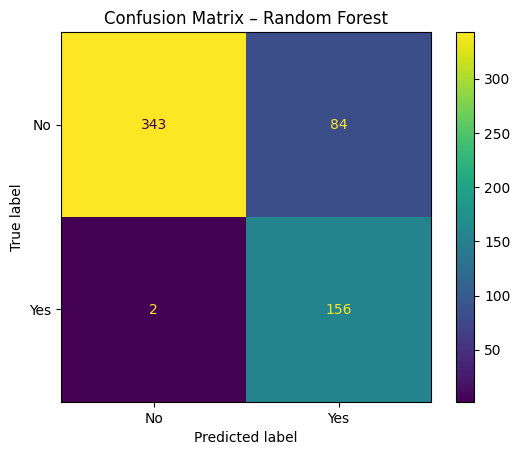

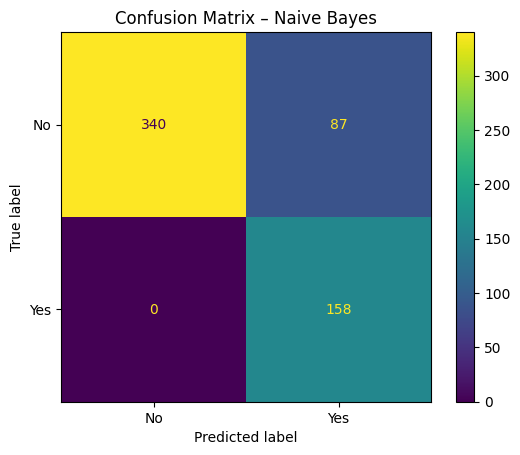

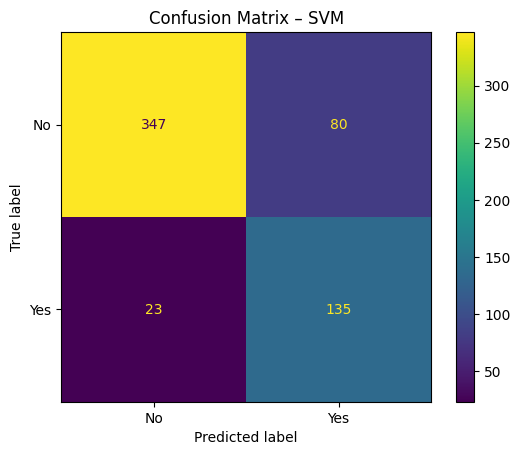

In [82]:
for name in top_3_models:
    model = best_models[name]
    y_pred = model.predict(X_test)

    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred
    )
    plt.title(f"Confusion Matrix – {name}")
    plt.show()


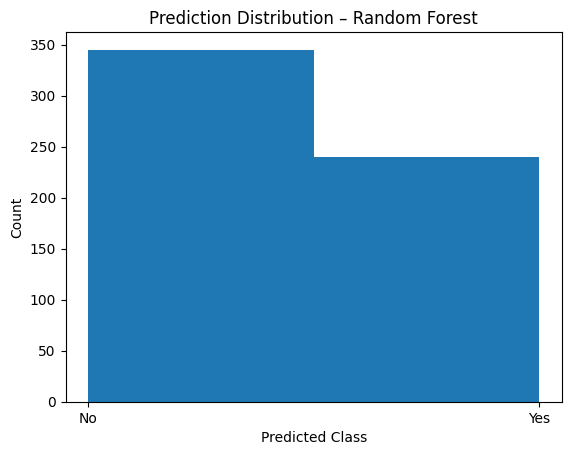

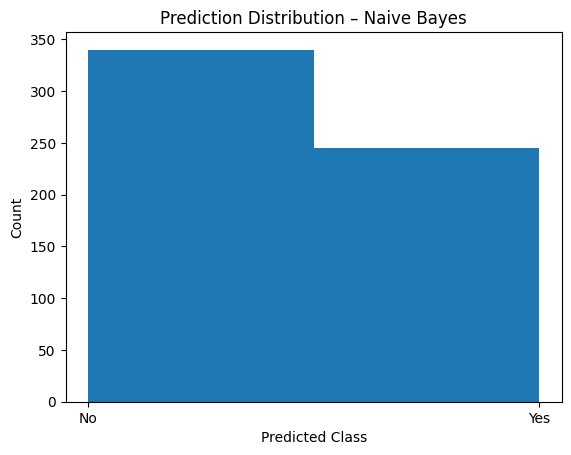

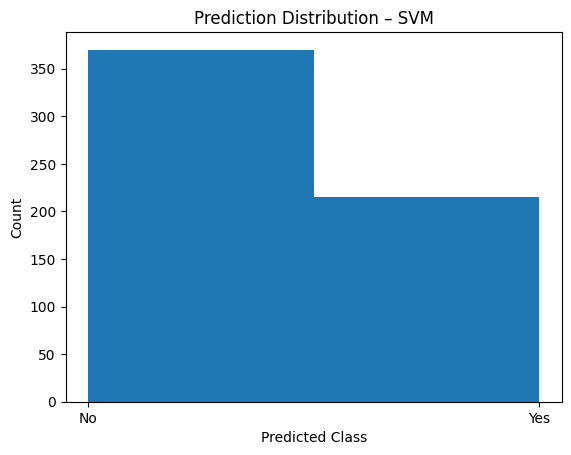

In [83]:
for name in top_3_models:
    model = best_models[name]
    y_pred = model.predict(X_test)

    plt.hist(y_pred, bins=2)
    plt.title(f"Prediction Distribution – {name}")
    plt.xlabel("Predicted Class")
    plt.ylabel("Count")
    plt.show()


### Interpretation
- Tree-based models capture complex shopping behavior patterns
- Linear models perform well but struggle with the non-linear relationships
- Purchase frequency and previous purchases strongly influence the predictions